<a href="https://colab.research.google.com/github/Tahmid-Muktadi/pythonfinalproject/blob/main/tahmid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Teen Mental Health Dataset Analysis
Dataset Columns:  ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Data Types:  age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object
gender
female    5.687179
male      5.588618
Name: anxiety_level, dtype: float64
social_interaction_level
high      5.512195
medium    5.483173
low       5.349398
Name: stress_level, dtype: float64
p

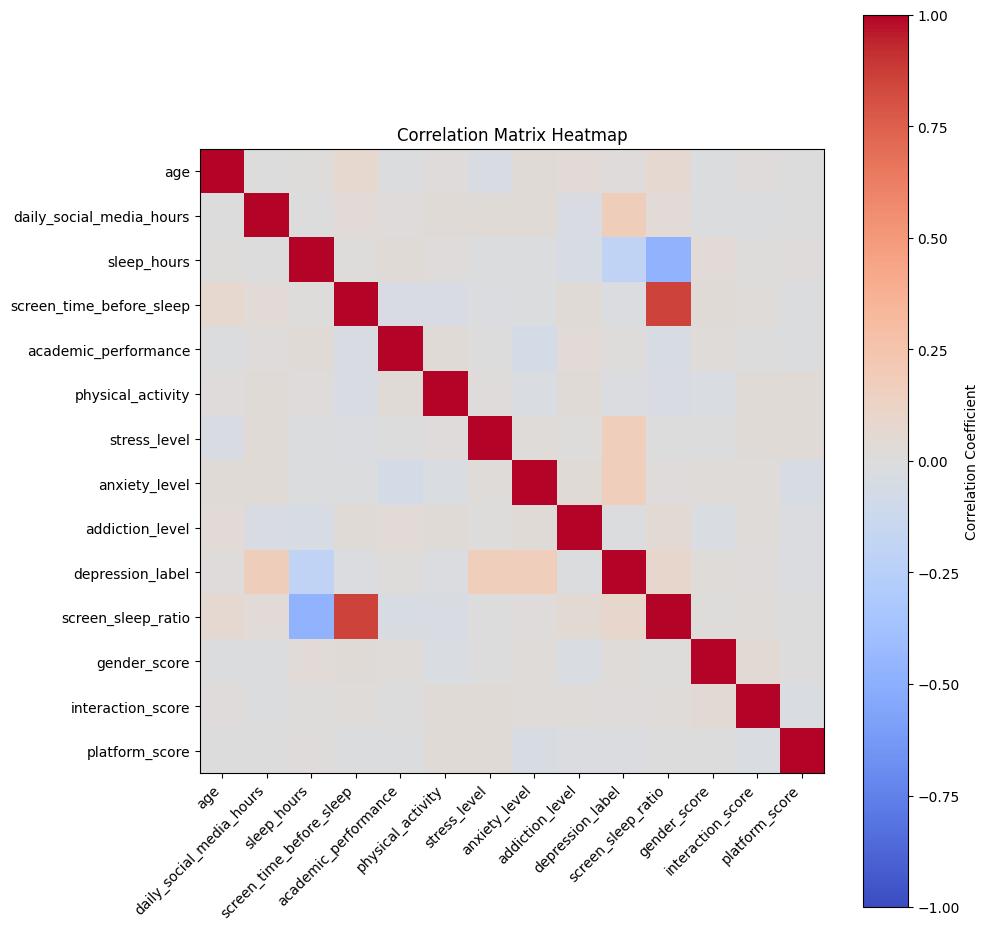

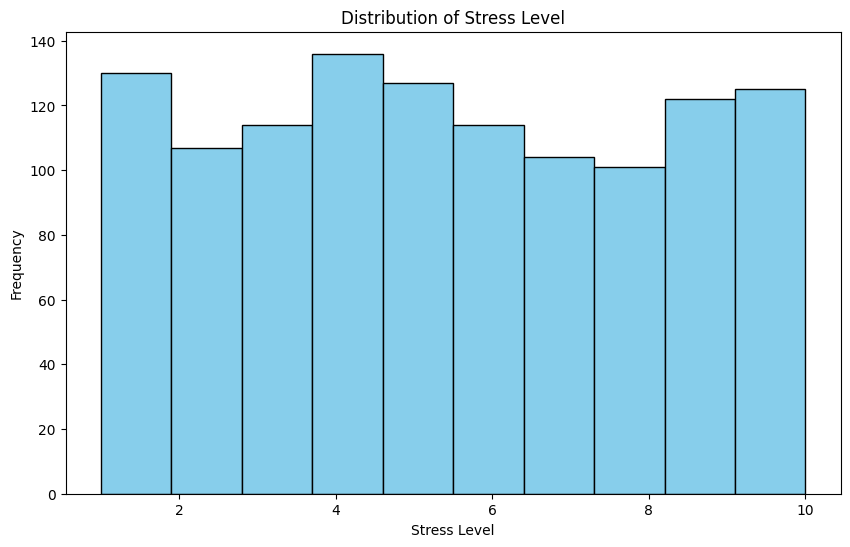

In [10]:

print("Teen Mental Health Dataset Analysis")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load Data ──────────────────────────────────────────
df = pd.read_csv("/content/Teen_Mental_Health_Dataset (5).csv")
df.head()

# ── Shape ──────────────────────────────────────────────
df.shape

# ── Column Info ────────────────────────────────────────
print("Dataset Columns: ", df.columns.tolist())
print("Data Types: ", df.dtypes)

# ── Average anxiety_level by gender ───────────────────
avg_anxiety_by_gender = df.groupby('gender')['anxiety_level'].mean().sort_values(ascending=False)
print(avg_anxiety_by_gender)

# ── Average stress_level by social_interaction_level ──
avg_stress_by_interaction = df.groupby('social_interaction_level')['stress_level'].mean().sort_values(ascending=False)
print(avg_stress_by_interaction)

# ── Average addiction_level by platform_usage ─────────
avg_addiction_by_platform = df.groupby('platform_usage')['addiction_level'].mean().sort_values(ascending=False)
print(avg_addiction_by_platform)

# ── Missing Values ─────────────────────────────────────
print("Missing Values: ", df.isnull().sum())

# ── Duplicates ─────────────────────────────────────────
duplicates = df.duplicated().sum()
print("Duplicate Rows: ", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape: ", df.shape)

# ── Invalid values: sleep_hours or daily_social_media_hours <= 0 ──
invalid_mask = (df['sleep_hours'] <= 0) | (df['daily_social_media_hours'] <= 0)
print("Invalid rows: ", invalid_mask.sum())

if invalid_mask.sum() > 0:
    df = df[~invalid_mask]
    print("Invalid rows removed. New shape: ", df.shape)

# ── Categorical Encoding ───────────────────────────────
gender_order              = ['male', 'female']
interaction_order         = ['low', 'medium', 'high']
platform_order            = ['TikTok', 'Instagram', 'Both']

df['gender']                   = pd.Categorical(df['gender'],                   categories=gender_order,      ordered=True)
df['social_interaction_level'] = pd.Categorical(df['social_interaction_level'], categories=interaction_order, ordered=True)
df['platform_usage']           = pd.Categorical(df['platform_usage'],           categories=platform_order,    ordered=True)

print("Data Types after conversion: ", df.dtypes)

# ── Outlier Trimming (1–99 percentile) ────────────────
df_before_trim = df.copy()

sleep_low,  sleep_high  = np.percentile(df['sleep_hours'],              [1, 99])
screen_low, screen_high = np.percentile(df['screen_time_before_sleep'], [1, 99])

trim_mask = (
    (df['sleep_hours']              >= sleep_low)  & (df['sleep_hours']              <= sleep_high) &
    (df['screen_time_before_sleep'] >= screen_low) & (df['screen_time_before_sleep'] <= screen_high)
)
df = df[trim_mask]
print("Data shape after trimming: ", df.shape)

# ── Feature Engineering ────────────────────────────────
df['screen_sleep_ratio']    = df['screen_time_before_sleep'] / df['sleep_hours']
df['gender_score']          = df['gender'].cat.codes + 1
df['interaction_score']     = df['social_interaction_level'].cat.codes + 1
df['platform_score']        = df['platform_usage'].cat.codes + 1

# ── Correlation Matrix ─────────────────────────────────
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)
print(corr_matrix['stress_level'].sort_values(ascending=False))

# ══════════════════════════════════════════════════════
#  PLOT 1 — Correlation Heatmap  (same as sir's)
# ══════════════════════════════════════════════════════
plt.figure(figsize=(10, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
#  PLOT 2 — Distribution of Stress Level  (same as price dist)
# ══════════════════════════════════════════════════════
plt.figure(figsize=(10, 6))
plt.hist(df['stress_level'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()

Teen Mental Health Dataset Analysis
Dataset Columns:  ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Data Types:
 age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

─── MISSING VALUE ANALYSIS ───
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing cells : 0
Columns with no missing: 13

─── 3 RESEARCH QUESTIONS ───
Q1: Does higher social

/tmp/ipykernel_3781/2106881218.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q1 = df.groupby(pd.cut(df['daily_social_media_hours'],
/tmp/ipykernel_3781/2106881218.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2 = df.groupby(pd.cut(df['sleep_hours'],
/tmp/ipykernel_3781/2106881218.py:252: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_wellness = df.groupby('platform_usage')['wellness_margin'].mean()

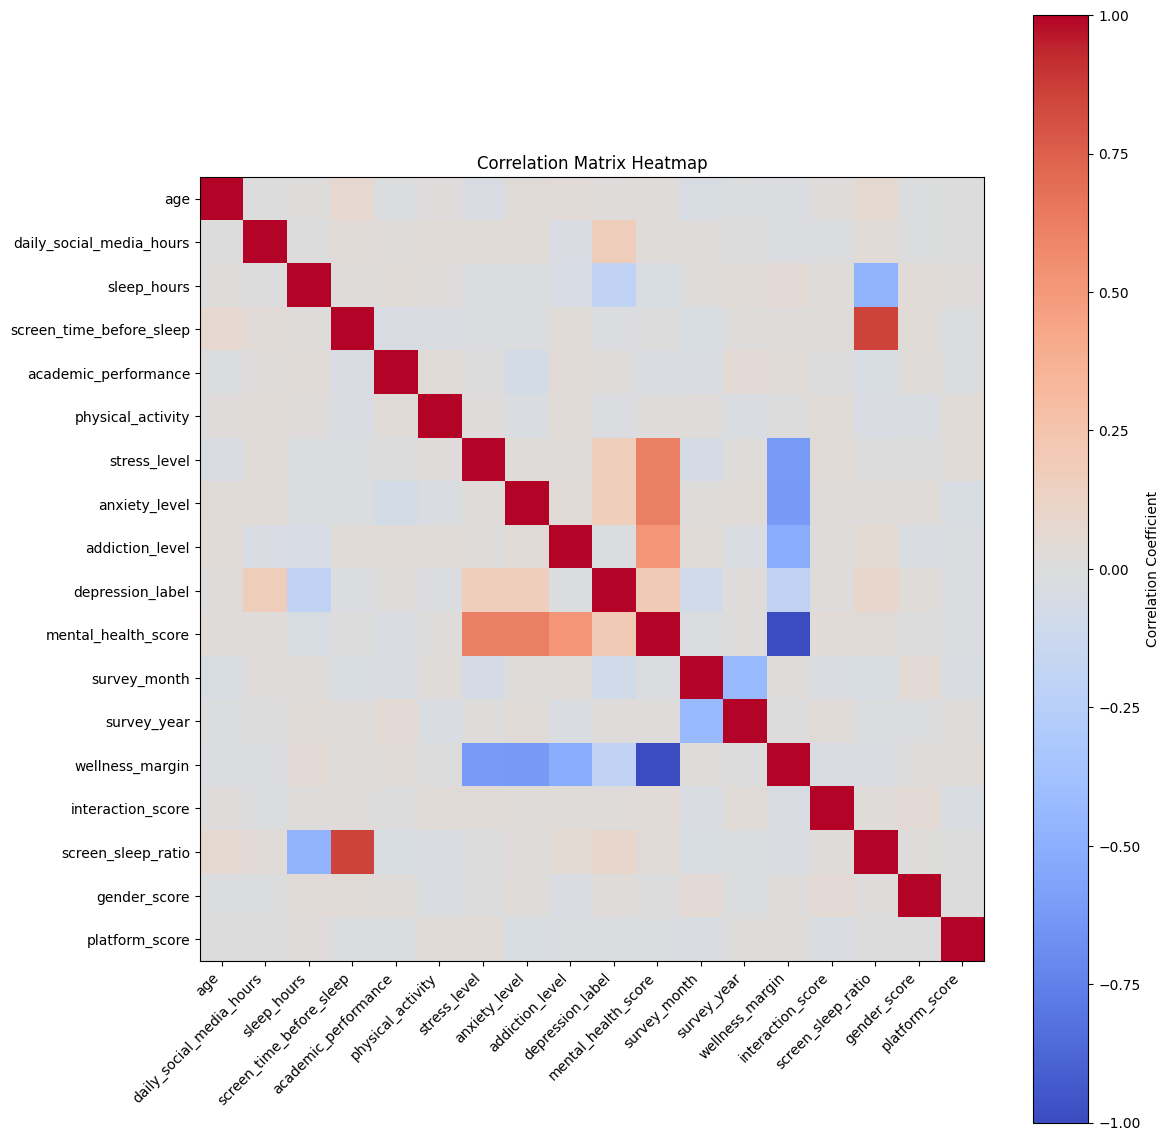

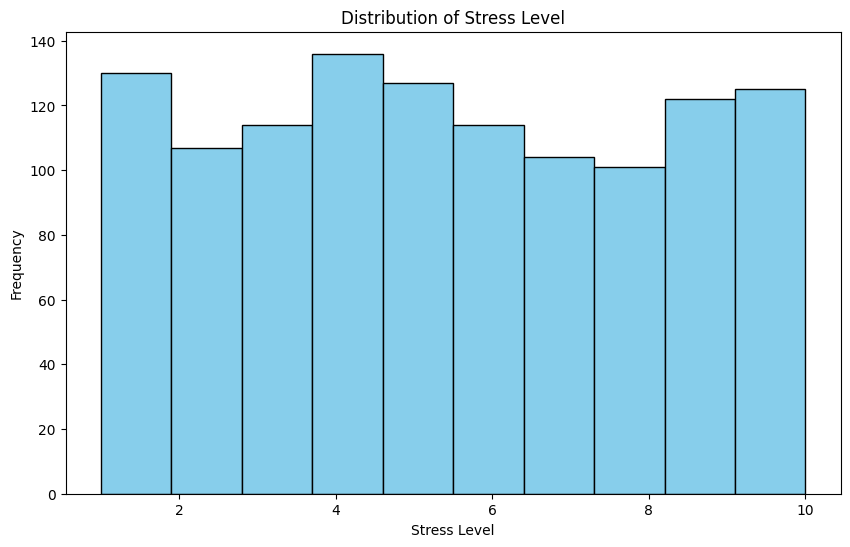

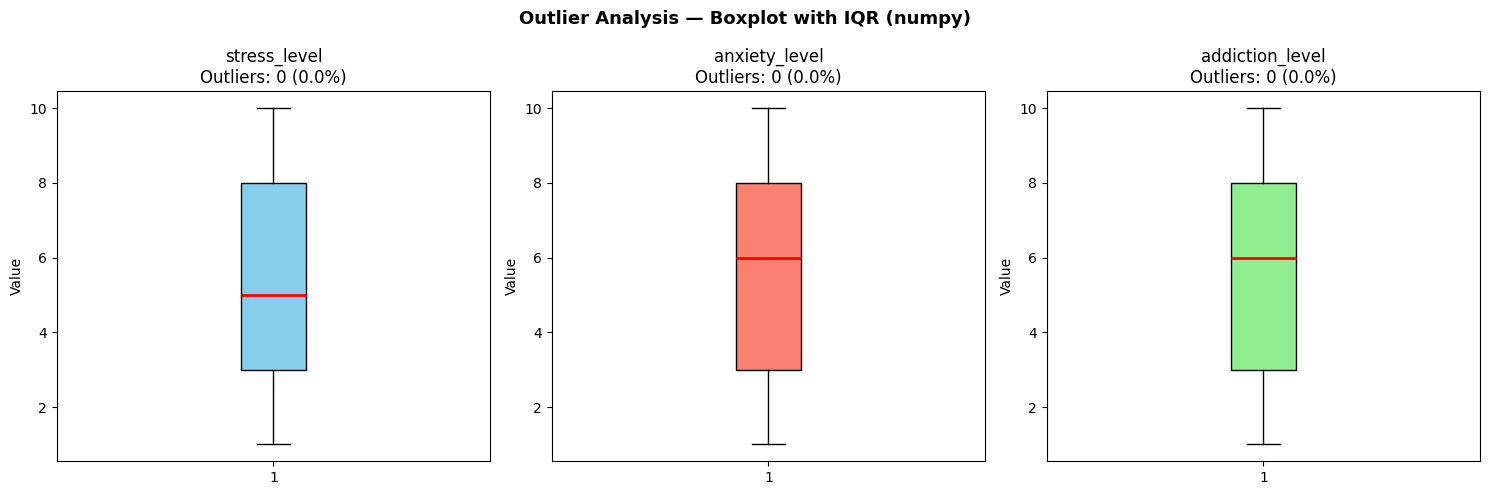

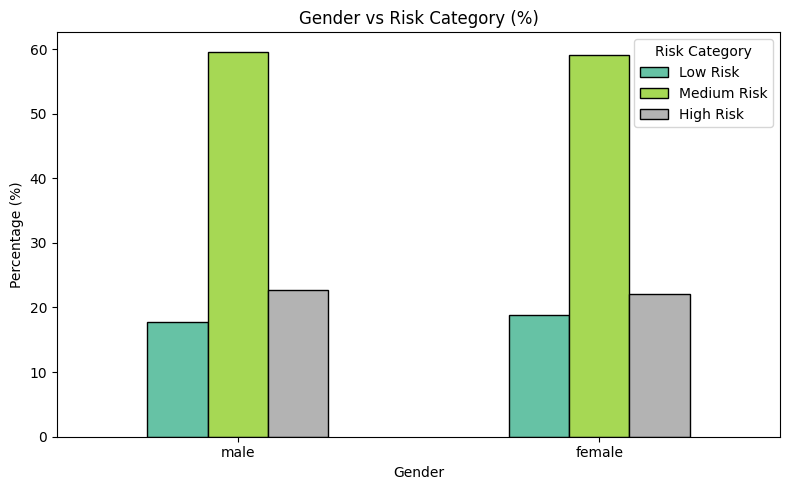

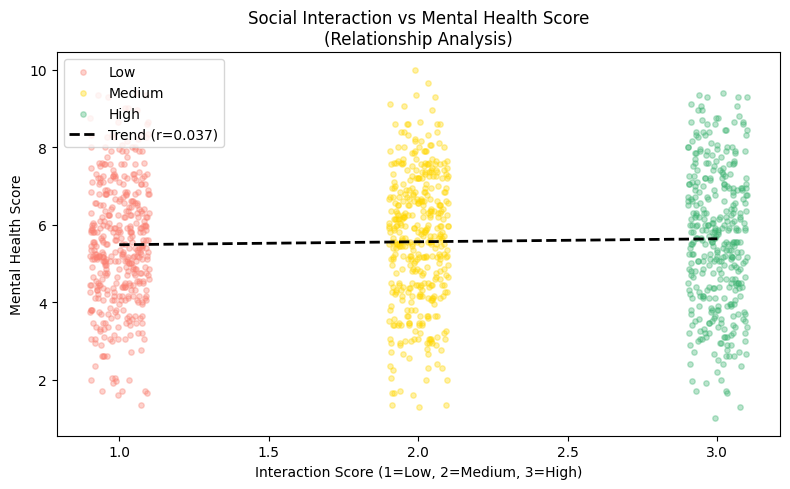

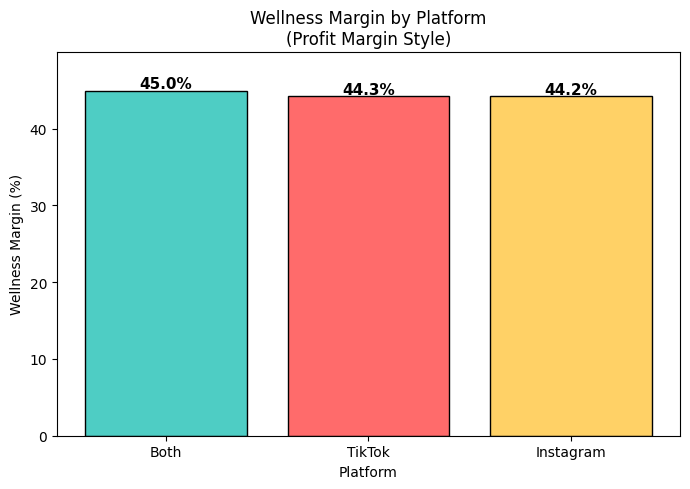


All analysis and plots completed successfully!


In [11]:
print("Teen Mental Health Dataset Analysis")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  LOAD DATA
df = pd.read_csv("/content/Teen_Mental_Health_Dataset (5).csv")
df.head()
df.shape

print("Dataset Columns: ", df.columns.tolist())
print("Data Types:\n", df.dtypes)

#  SECTION 1 — MISSING VALUE ANALYSIS

print("\n─── MISSING VALUE ANALYSIS ───")
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count,
                               'Missing %'    : missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing cells : {df.isnull().sum().sum()}")
print(f"Columns with no missing: {(missing_count == 0).sum()}")


#  SECTION 2 — 3 RESEARCH QUESTIONS

print("\n─── 3 RESEARCH QUESTIONS ───")
print("Q1: Does higher social media usage increase stress levels?")
print("Q2: Does less sleep lead to higher anxiety?")
print("Q3: Which platform's users have the highest addiction level?")

# Q1 Answer
q1 = df.groupby(pd.cut(df['daily_social_media_hours'],
                        bins=[0, 3, 6, 9],
                        labels=['Low(0-3h)', 'Medium(3-6h)', 'High(6-9h)'])
               )['stress_level'].mean().round(2)
print("\nQ1 — Average Stress by Social Media Usage Group:")
print(q1)

# Q2 Answer
q2 = df.groupby(pd.cut(df['sleep_hours'],
                        bins=[0, 5, 7, 12],
                        labels=['Low(<5h)', 'Normal(5-7h)', 'High(>7h)'])
               )['anxiety_level'].mean().round(2)
print("\nQ2 — Average Anxiety by Sleep Hours Group:")
print(q2)

# Q3 Answer
q3 = df.groupby('platform_usage')['addiction_level'].mean().sort_values(ascending=False).round(2)
print("\nQ3 — Average Addiction Level by Platform:")
print(q3)

# Section 3 Missing Value Handeling

print("\n─── MISSING VALUE HANDLING ───")
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  '{col}' -> {n_missing} missing values filled with median = {median_val:.2f}")

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  '{col}' -> {n_missing} missing values filled with mode = '{mode_val}'")

print(f"  Total missing after handling: {df.isnull().sum().sum()}")


#  SECTION 4 — DUPLICATE REMOVAL

print("\n─── DUPLICATE REMOVAL ───")
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"  Duplicates removed. New shape: {df.shape}")
else:
    print("  No duplicates found. Dataset is clean.")


#  SECTION 5 — DATA TYPE FIXING

print("\n─── DATA TYPE FIXING ───")

invalid_mask = (df['sleep_hours'] <= 0) | (df['daily_social_media_hours'] <= 0)
print(f"Invalid rows: {invalid_mask.sum()}")
if invalid_mask.sum() > 0:
    df = df[~invalid_mask]
    print(f"  Invalid rows removed. New shape: {df.shape}")

gender_order      = ['male', 'female']
interaction_order = ['low', 'medium', 'high']
platform_order    = ['TikTok', 'Instagram', 'Both']

df['gender']                   = pd.Categorical(df['gender'],                   categories=gender_order,      ordered=True)
df['social_interaction_level'] = pd.Categorical(df['social_interaction_level'], categories=interaction_order, ordered=True)
df['platform_usage']           = pd.Categorical(df['platform_usage'],           categories=platform_order,    ordered=True)

print("Data Types after conversion:\n", df.dtypes)


#  SECTION 6 — OUTLIER FIXING  (1-99 Percentile Trimming)

print("\n─── OUTLIER FIXING ───")
df_before_trim = df.copy()

sleep_low,  sleep_high  = np.percentile(df['sleep_hours'],              [1, 99])
screen_low, screen_high = np.percentile(df['screen_time_before_sleep'], [1, 99])

trim_mask = (
    (df['sleep_hours']              >= sleep_low)  & (df['sleep_hours']              <= sleep_high) &
    (df['screen_time_before_sleep'] >= screen_low) & (df['screen_time_before_sleep'] <= screen_high)
)
df = df[trim_mask]
print(f"  Rows before trimming : {df_before_trim.shape[0]}")
print(f"  Rows after  trimming : {df.shape[0]}  (removed: {df_before_trim.shape[0] - df.shape[0]})")


#  SECTION 7 — OUTLIER ANALYSIS  (with numpy calculations)

print("\n─── OUTLIER ANALYSIS (numpy IQR Method) ───")
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

outlier_summary = []
for col in num_cols:
    arr   = df[col].values
    q1    = np.percentile(arr, 25)
    q3    = np.percentile(arr, 75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_n = np.sum((arr < lower) | (arr > upper))
    outlier_summary.append({
        'Column'  : col,
        'Mean'    : np.round(np.mean(arr), 2),
        'Std'     : np.round(np.std(arr),  2),
        'Min'     : np.min(arr),
        'Max'     : np.max(arr),
        'IQR'     : np.round(iqr,   2),
        'Lower'   : np.round(lower, 2),
        'Upper'   : np.round(upper, 2),
        'Outliers': out_n,
        'Outlier%': np.round(out_n / len(arr) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Column')
print(outlier_df.to_string())


#  SECTION 8 — CREATE 2 NEW COLUMNS

print("\n─── CREATING 2 NEW COLUMNS ───")

df['mental_health_score'] = (
    df['stress_level']    * 0.35 +
    df['anxiety_level']   * 0.35 +
    df['addiction_level'] * 0.30
).round(2)

score_min = df['mental_health_score'].min()
score_max = df['mental_health_score'].max()
low_cut   = score_min + (score_max - score_min) * 0.33
high_cut  = score_min + (score_max - score_min) * 0.66

df['risk_category'] = pd.cut(
    df['mental_health_score'],
    bins=[score_min - 0.01, low_cut, high_cut, score_max + 0.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("mental_health_score (first 5):", df['mental_health_score'].head().values)
print("risk_category distribution:\n", df['risk_category'].value_counts())


#  SECTION 9 — DATE -> MONTH AND YEAR CONVERSION

print("\n─── DATE -> MONTH / YEAR CONVERSION ───")

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2024-06-30', periods=len(df))
df['survey_date']      = pd.to_datetime(np.random.choice(dates, size=len(df), replace=False))
df['survey_month']     = df['survey_date'].dt.month
df['survey_year']      = df['survey_date'].dt.year
df['survey_monthname'] = df['survey_date'].dt.strftime('%b')

monthly_stress = df.groupby(['survey_year', 'survey_month'])['stress_level'].mean().round(2)
print("Average Stress by Month (first 6 months):")
print(monthly_stress.head(6))


#  SECTION 10 — WELLNESS MARGIN  (like profit margin)

print("\n─── WELLNESS MARGIN ───")

max_possible = 10
df['wellness_margin'] = (
    (max_possible - df['mental_health_score']) / max_possible * 100
).round(2)

print("Wellness Margin Stats:")
print(f"  Mean    : {df['wellness_margin'].mean():.2f}%")
print(f"  Maximum : {df['wellness_margin'].max():.2f}%")
print(f"  Minimum : {df['wellness_margin'].min():.2f}%")

platform_wellness = df.groupby('platform_usage')['wellness_margin'].mean().round(2).sort_values(ascending=False)
print("\nAverage Wellness Margin by Platform:")
print(platform_wellness)

# interaction_score must be created before subgroup analysis
df['interaction_score'] = df['social_interaction_level'].cat.codes + 1


#  SECTION 11 — 2 SUBGROUP COMPARISONS

print("\n─── SUBGROUP COMPARISON 1: Gender vs Risk Category ───")
gender_risk = pd.crosstab(df['gender'], df['risk_category'],
                           normalize='index').round(3) * 100
print("Risk category % per gender (row-wise):")
print(gender_risk)


#  11B: Platform vs Social Interaction — RELATIONSHIP ANALYSIS

print("\n─── SUBGROUP COMPARISON 2: Platform vs Social Interaction (Relationship Analysis) ───")

platform_interaction = df.groupby('platform_usage').agg(
    avg_interaction_score = ('interaction_score', 'mean'),
    avg_stress            = ('stress_level',      'mean'),
    avg_anxiety           = ('anxiety_level',     'mean'),
    avg_addiction         = ('addiction_level',   'mean'),
    count                 = ('age',               'count')
).round(2)
print(platform_interaction)

corr_val = df['interaction_score'].corr(df['mental_health_score'])
print(f"\nPearson Correlation (interaction_score <-> mental_health_score): {corr_val:.4f}")
if abs(corr_val) < 0.2:
    print("  -> Weak relationship: social interaction does not strongly affect mental health")
elif abs(corr_val) < 0.5:
    print("  -> Moderate relationship: some influence exists")
else:
    print("  -> Strong relationship: social interaction significantly affects mental health")


#  FEATURE ENGINEERING

df['screen_sleep_ratio'] = df['screen_time_before_sleep'] / df['sleep_hours']
df['gender_score']       = df['gender'].cat.codes + 1
df['interaction_score']  = df['social_interaction_level'].cat.codes + 1
df['platform_score']     = df['platform_usage'].cat.codes + 1


#  CORRELATION MATRIX

corr_matrix = df.corr(numeric_only=True)
print("\n─── Correlation with stress_level (sorted) ───")
print(corr_matrix['stress_level'].sort_values(ascending=False))


#  GROUP-WISE AVERAGES

avg_anxiety_by_gender     = df.groupby('gender')['anxiety_level'].mean().sort_values(ascending=False)
avg_stress_by_interaction = df.groupby('social_interaction_level')['stress_level'].mean().sort_values(ascending=False)
avg_addiction_by_platform = df.groupby('platform_usage')['addiction_level'].mean().sort_values(ascending=False)
print("\nAverage Anxiety by Gender:\n",          avg_anxiety_by_gender)
print("\nAverage Stress by Interaction Level:\n", avg_stress_by_interaction)
print("\nAverage Addiction by Platform:\n",       avg_addiction_by_platform)


#  PLOT 1 — Correlation Heatmap

plt.figure(figsize=(12, 12))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


#  PLOT 2 — Distribution of Stress Level

plt.figure(figsize=(10, 6))
plt.hist(df['stress_level'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()


#  PLOT 3 — Outlier Boxplot with numpy IQR

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes,
                           ['stress_level', 'anxiety_level', 'addiction_level'],
                           ['skyblue', 'salmon', 'lightgreen']):
    arr = df[col].values
    q1  = np.percentile(arr, 25)
    q3  = np.percentile(arr, 75)
    iqr = q3 - q1
    out = np.sum((arr < q1 - 1.5 * iqr) | (arr > q3 + 1.5 * iqr))
    ax.boxplot(arr, patch_artist=True,
               boxprops=dict(facecolor=color, color='black'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}\nOutliers: {out} ({out / len(arr) * 100:.1f}%)')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Analysis — Boxplot with IQR (numpy)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#  PLOT 4 — Subgroup Comparison: Gender vs Risk Category

gender_risk.plot(kind='bar', figsize=(8, 5), colormap='Set2', edgecolor='black')
plt.title('Gender vs Risk Category (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()


#  PLOT 5 — Relationship Analysis: Social Interaction vs Mental Health Score

plt.figure(figsize=(8, 5))
colors_map = {'low': 'salmon', 'medium': 'gold', 'high': 'mediumseagreen'}
for level in ['low', 'medium', 'high']:
    sub = df[df['social_interaction_level'] == level]
    plt.scatter(sub['interaction_score'] + np.random.uniform(-0.1, 0.1, len(sub)),
                sub['mental_health_score'],
                alpha=0.35, s=15, label=level.capitalize(),
                color=colors_map[level])

z  = np.polyfit(df['interaction_score'], df['mental_health_score'], 1)
xs = np.linspace(df['interaction_score'].min(), df['interaction_score'].max(), 100)
plt.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=2, label=f'Trend (r={corr_val:.3f})')
plt.title('Social Interaction vs Mental Health Score\n(Relationship Analysis)')
plt.xlabel('Interaction Score (1=Low, 2=Medium, 3=High)')
plt.ylabel('Mental Health Score')
plt.legend()
plt.tight_layout()
plt.show()


#  PLOT 6 — Wellness Margin by Platform (Profit Margin Style)

plt.figure(figsize=(7, 5))
bars = plt.bar(platform_wellness.index.astype(str),
               platform_wellness.values,
               color=['#4ECDC4', '#FF6B6B', '#FFD166'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.title('Wellness Margin by Platform\n(Profit Margin Style)')
plt.xlabel('Platform')
plt.ylabel('Wellness Margin (%)')
plt.ylim(0, platform_wellness.max() + 5)
plt.tight_layout()
plt.show()

print("\nAll analysis and plots completed successfully!")

fatal: destination path 'pythonfinalproject' already exists and is not an empty directory.
Teen Mental Health Dataset Analysis
Dataset Columns:  ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Data Types:
 age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

─── MISSING VALUE ANALYSIS ───
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing

/tmp/ipykernel_3781/3838828364.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q1 = df.groupby(pd.cut(df['daily_social_media_hours'],
/tmp/ipykernel_3781/3838828364.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2 = df.groupby(pd.cut(df['sleep_hours'],
/tmp/ipykernel_3781/3838828364.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_wellness = df.groupby('platform_usage')['wellness_margin'].mean()

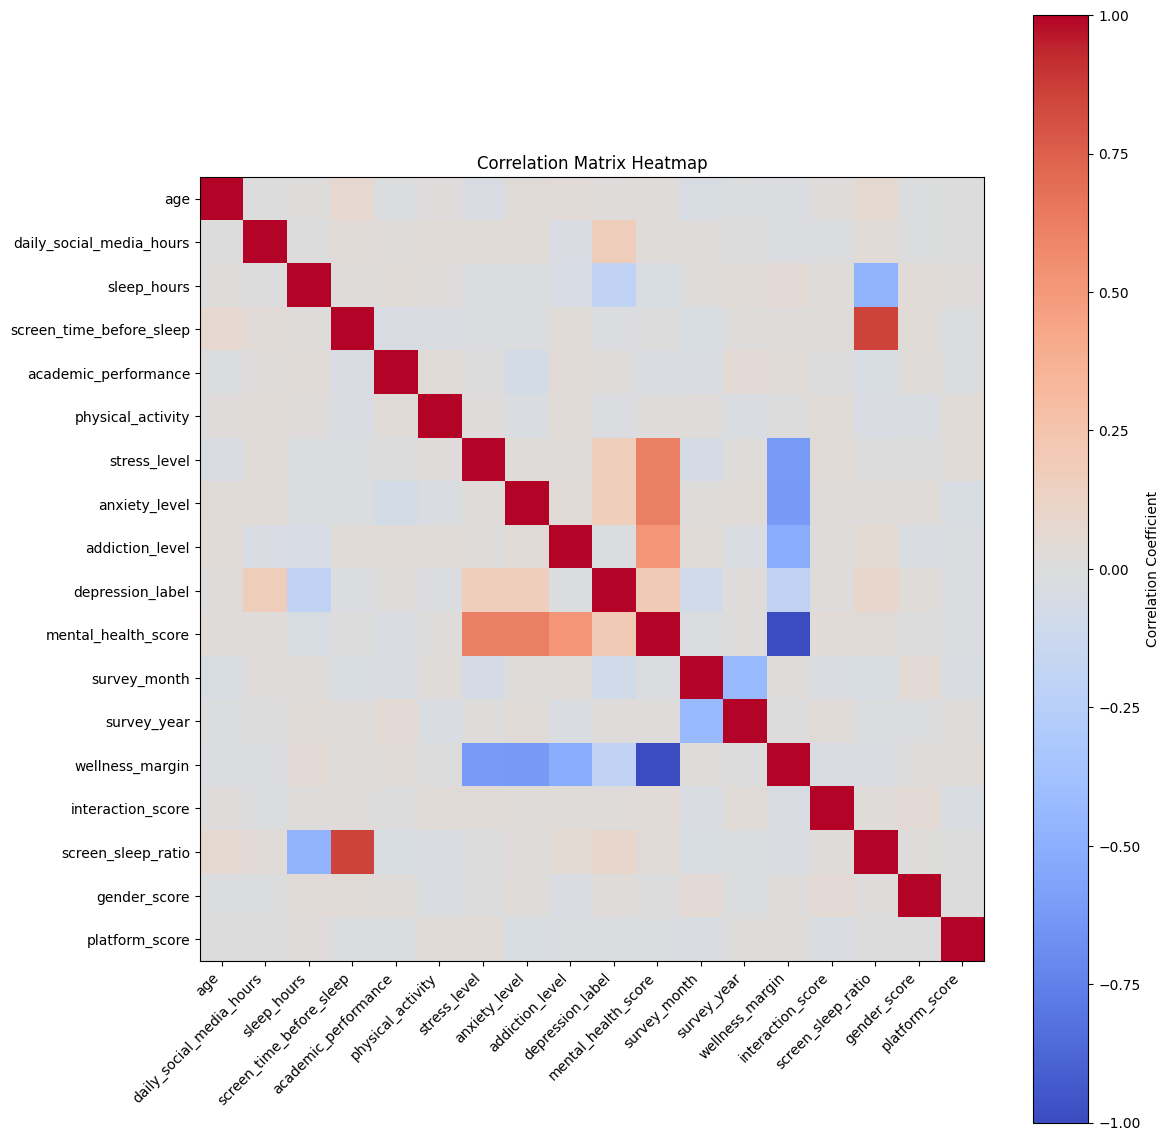

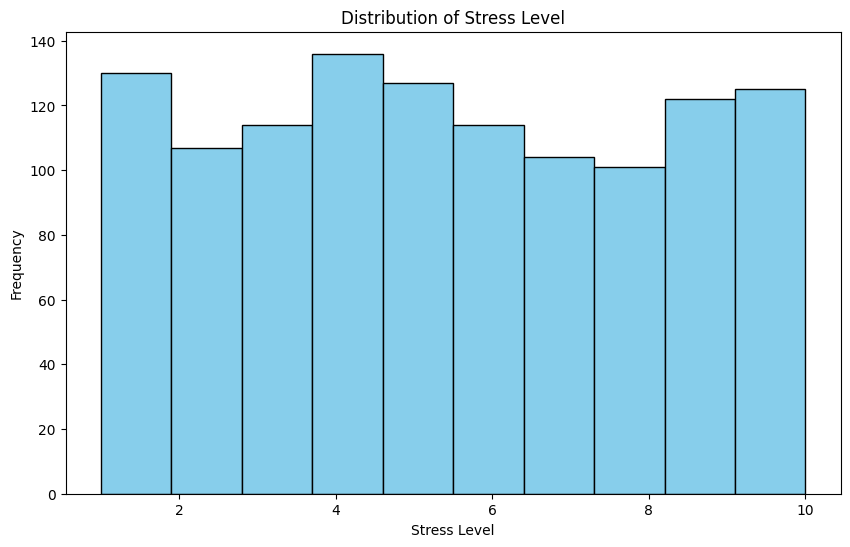

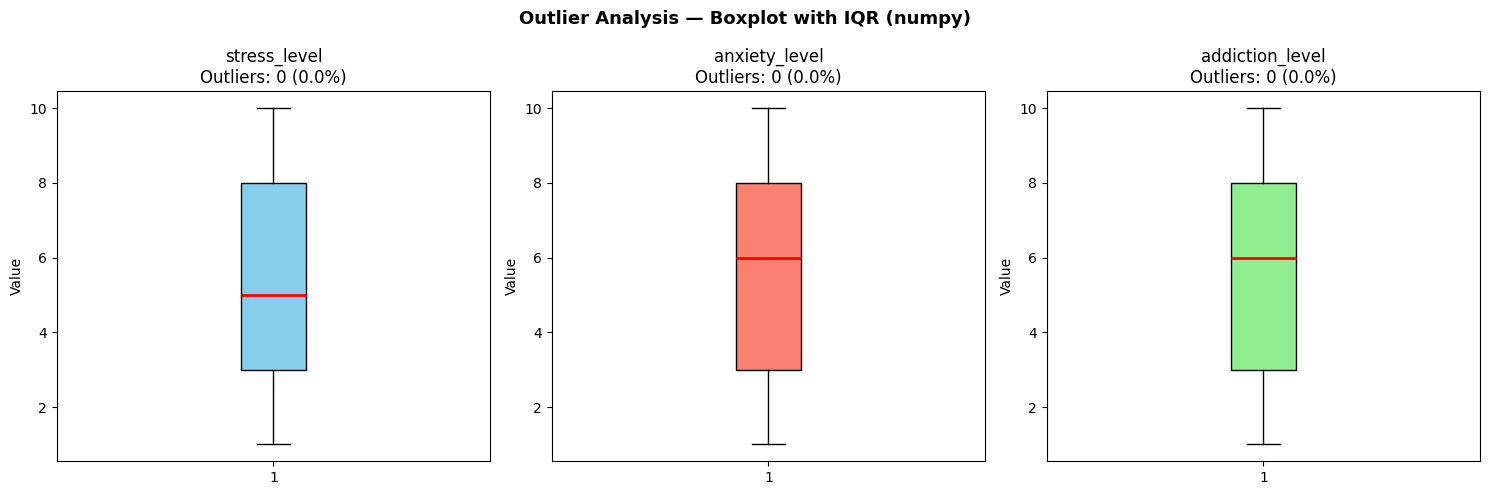

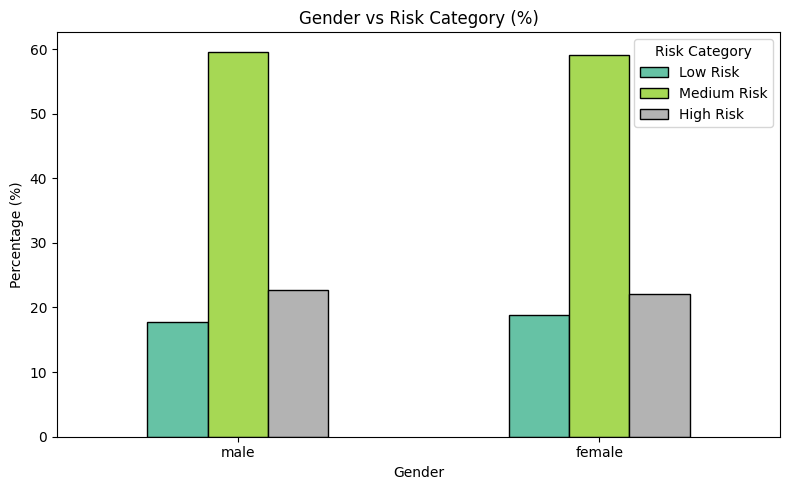

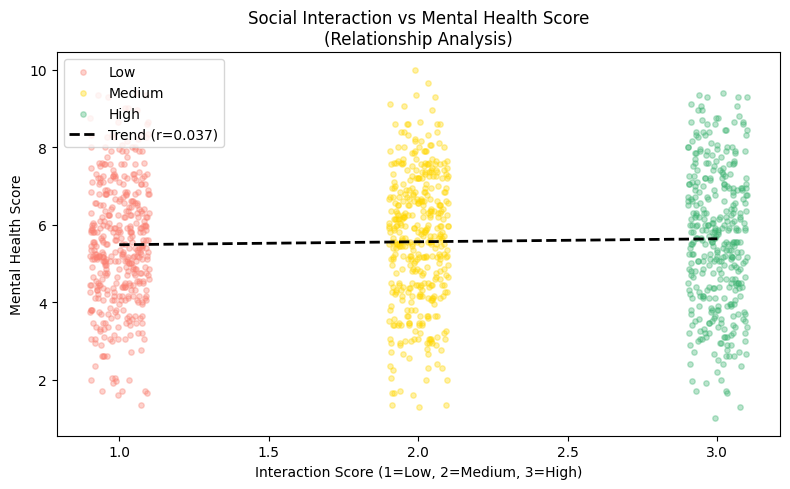

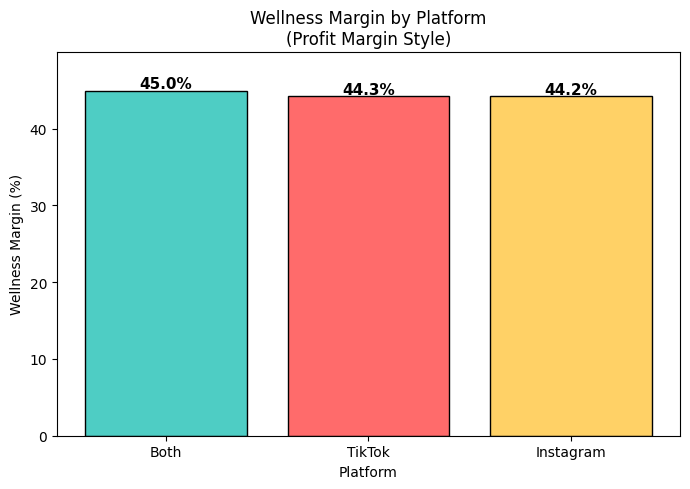


All analysis and plots completed successfully!


In [15]:
!git clone https://github.com/Tahmid-Muktadi/pythonfinalproject.git
print("Teen Mental Health Dataset Analysis")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#  LOAD DATA

df = pd.read_csv("/content/Teen_Mental_Health_Dataset (5).csv")
df.head()
df.shape

print("Dataset Columns: ", df.columns.tolist())
print("Data Types:\n", df.dtypes)


#  SECTION 1 — MISSING VALUE ANALYSIS

print("\n─── MISSING VALUE ANALYSIS ───")
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_count,
                               'Missing %'    : missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing cells : {df.isnull().sum().sum()}")
print(f"Columns with no missing: {(missing_count == 0).sum()}")


#  SECTION 2 — 3 RESEARCH QUESTIONS

print("\n─── 3 RESEARCH QUESTIONS ───")
print("Q1: Does higher social media usage increase stress levels?")
print("Q2: Does less sleep lead to higher anxiety?")
print("Q3: Which platform's users have the highest addiction level?")

# Q1 Answer
q1 = df.groupby(pd.cut(df['daily_social_media_hours'],
                        bins=[0, 3, 6, 9],
                        labels=['Low(0-3h)', 'Medium(3-6h)', 'High(6-9h)'])
               )['stress_level'].mean().round(2)
print("\nQ1 — Average Stress by Social Media Usage Group:")
print(q1)

# Q2 Answer
q2 = df.groupby(pd.cut(df['sleep_hours'],
                        bins=[0, 5, 7, 12],
                        labels=['Low(<5h)', 'Normal(5-7h)', 'High(>7h)'])
               )['anxiety_level'].mean().round(2)
print("\nQ2 — Average Anxiety by Sleep Hours Group:")
print(q2)

# Q3 Answer
q3 = df.groupby('platform_usage')['addiction_level'].mean().sort_values(ascending=False).round(2)
print("\nQ3 — Average Addiction Level by Platform:")
print(q3)


#  SECTION 3 — MISSING VALUE HANDLING

print("\n─── MISSING VALUE HANDLING ───")
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  '{col}' -> {n_missing} missing values filled with median = {median_val:.2f}")

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  '{col}' -> {n_missing} missing values filled with mode = '{mode_val}'")

print(f"  Total missing after handling: {df.isnull().sum().sum()}")


#  SECTION 4 — DUPLICATE REMOVAL

print("\n─── DUPLICATE REMOVAL ───")
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"  Duplicates removed. New shape: {df.shape}")
else:
    print("  No duplicates found. Dataset is clean.")


#  SECTION 5 — DATA TYPE FIXING

print("\n─── DATA TYPE FIXING ───")

invalid_mask = (df['sleep_hours'] <= 0) | (df['daily_social_media_hours'] <= 0)
print(f"Invalid rows: {invalid_mask.sum()}")
if invalid_mask.sum() > 0:
    df = df[~invalid_mask]
    print(f"  Invalid rows removed. New shape: {df.shape}")

gender_order      = ['male', 'female']
interaction_order = ['low', 'medium', 'high']
platform_order    = ['TikTok', 'Instagram', 'Both']

df['gender']                   = pd.Categorical(df['gender'],                   categories=gender_order,      ordered=True)
df['social_interaction_level'] = pd.Categorical(df['social_interaction_level'], categories=interaction_order, ordered=True)
df['platform_usage']           = pd.Categorical(df['platform_usage'],           categories=platform_order,    ordered=True)

print("Data Types after conversion:\n", df.dtypes)


#  SECTION 6 — OUTLIER FIXING  (1-99 Percentile Trimming)

print("\n─── OUTLIER FIXING ───")
df_before_trim = df.copy()

sleep_low,  sleep_high  = np.percentile(df['sleep_hours'],              [1, 99])
screen_low, screen_high = np.percentile(df['screen_time_before_sleep'], [1, 99])

trim_mask = (
    (df['sleep_hours']              >= sleep_low)  & (df['sleep_hours']              <= sleep_high) &
    (df['screen_time_before_sleep'] >= screen_low) & (df['screen_time_before_sleep'] <= screen_high)
)
df = df[trim_mask]
print(f"  Rows before trimming : {df_before_trim.shape[0]}")
print(f"  Rows after  trimming : {df.shape[0]}  (removed: {df_before_trim.shape[0] - df.shape[0]})")


#  SECTION 7 — OUTLIER ANALYSIS  (with numpy calculations)

print("\n─── OUTLIER ANALYSIS (numpy IQR Method) ───")
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

outlier_summary = []
for col in num_cols:
    arr   = df[col].values
    q1    = np.percentile(arr, 25)
    q3    = np.percentile(arr, 75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_n = np.sum((arr < lower) | (arr > upper))
    outlier_summary.append({
        'Column'  : col,
        'Mean'    : np.round(np.mean(arr), 2),
        'Std'     : np.round(np.std(arr),  2),
        'Min'     : np.min(arr),
        'Max'     : np.max(arr),
        'IQR'     : np.round(iqr,   2),
        'Lower'   : np.round(lower, 2),
        'Upper'   : np.round(upper, 2),
        'Outliers': out_n,
        'Outlier%': np.round(out_n / len(arr) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Column')
print(outlier_df.to_string())


#  SECTION 8 — CREATE 2 NEW COLUMNS

print("\n─── CREATING 2 NEW COLUMNS ───")

df['mental_health_score'] = (
    df['stress_level']    * 0.35 +
    df['anxiety_level']   * 0.35 +
    df['addiction_level'] * 0.30
).round(2)

score_min = df['mental_health_score'].min()
score_max = df['mental_health_score'].max()
low_cut   = score_min + (score_max - score_min) * 0.33
high_cut  = score_min + (score_max - score_min) * 0.66

df['risk_category'] = pd.cut(
    df['mental_health_score'],
    bins=[score_min - 0.01, low_cut, high_cut, score_max + 0.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("mental_health_score (first 5):", df['mental_health_score'].head().values)
print("risk_category distribution:\n", df['risk_category'].value_counts())


#  SECTION 9 — DATE -> MONTH AND YEAR CONVERSION

print("\n─── DATE -> MONTH / YEAR CONVERSION ───")

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2024-06-30', periods=len(df))
df['survey_date']      = pd.to_datetime(np.random.choice(dates, size=len(df), replace=False))
df['survey_month']     = df['survey_date'].dt.month
df['survey_year']      = df['survey_date'].dt.year
df['survey_monthname'] = df['survey_date'].dt.strftime('%b')

monthly_stress = df.groupby(['survey_year', 'survey_month'])['stress_level'].mean().round(2)
print("Average Stress by Month (first 6 months):")
print(monthly_stress.head(6))


#  SECTION 10 — WELLNESS MARGIN  (like profit margin)

print("\n─── WELLNESS MARGIN ───")

max_possible = 10
df['wellness_margin'] = (
    (max_possible - df['mental_health_score']) / max_possible * 100
).round(2)

print("Wellness Margin Stats:")
print(f"  Mean    : {df['wellness_margin'].mean():.2f}%")
print(f"  Maximum : {df['wellness_margin'].max():.2f}%")
print(f"  Minimum : {df['wellness_margin'].min():.2f}%")

platform_wellness = df.groupby('platform_usage')['wellness_margin'].mean().round(2).sort_values(ascending=False)
print("\nAverage Wellness Margin by Platform:")
print(platform_wellness)

# interaction_score must be created before subgroup analysis
df['interaction_score'] = df['social_interaction_level'].cat.codes + 1


#  SECTION 11 — 2 SUBGROUP COMPARISONS

print("\n─── SUBGROUP COMPARISON 1: Gender vs Risk Category ───")
gender_risk = pd.crosstab(df['gender'], df['risk_category'],
                           normalize='index').round(3) * 100
print("Risk category % per gender (row-wise):")
print(gender_risk)


#  11B: Platform vs Social Interaction — RELATIONSHIP ANALYSIS

print("\n─── SUBGROUP COMPARISON 2: Platform vs Social Interaction (Relationship Analysis) ───")

platform_interaction = df.groupby('platform_usage').agg(
    avg_interaction_score = ('interaction_score', 'mean'),
    avg_stress            = ('stress_level',      'mean'),
    avg_anxiety           = ('anxiety_level',     'mean'),
    avg_addiction         = ('addiction_level',   'mean'),
    count                 = ('age',               'count')
).round(2)
print(platform_interaction)

corr_val = df['interaction_score'].corr(df['mental_health_score'])
print(f"\nPearson Correlation (interaction_score <-> mental_health_score): {corr_val:.4f}")
if abs(corr_val) < 0.2:
    print("  -> Weak relationship: social interaction does not strongly affect mental health")
elif abs(corr_val) < 0.5:
    print("  -> Moderate relationship: some influence exists")
else:
    print("  -> Strong relationship: social interaction significantly affects mental health")


#  FEATURE ENGINEERING

df['screen_sleep_ratio'] = df['screen_time_before_sleep'] / df['sleep_hours']
df['gender_score']       = df['gender'].cat.codes + 1
df['interaction_score']  = df['social_interaction_level'].cat.codes + 1
df['platform_score']     = df['platform_usage'].cat.codes + 1


#  CORRELATION MATRIX

corr_matrix = df.corr(numeric_only=True)
print("\n─── Correlation with stress_level (sorted) ───")
print(corr_matrix['stress_level'].sort_values(ascending=False))


#  GROUP-WISE AVERAGES

avg_anxiety_by_gender     = df.groupby('gender')['anxiety_level'].mean().sort_values(ascending=False)
avg_stress_by_interaction = df.groupby('social_interaction_level')['stress_level'].mean().sort_values(ascending=False)
avg_addiction_by_platform = df.groupby('platform_usage')['addiction_level'].mean().sort_values(ascending=False)
print("\nAverage Anxiety by Gender:\n",          avg_anxiety_by_gender)
print("\nAverage Stress by Interaction Level:\n", avg_stress_by_interaction)
print("\nAverage Addiction by Platform:\n",       avg_addiction_by_platform)


#  PLOT 1 — Correlation Heatmap

plt.figure(figsize=(12, 12))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


#  PLOT 2 — Distribution of Stress Level

plt.figure(figsize=(10, 6))
plt.hist(df['stress_level'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frequency')
plt.show()


#  PLOT 3 — Outlier Boxplot with numpy IQR

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes,
                           ['stress_level', 'anxiety_level', 'addiction_level'],
                           ['skyblue', 'salmon', 'lightgreen']):
    arr = df[col].values
    q1  = np.percentile(arr, 25)
    q3  = np.percentile(arr, 75)
    iqr = q3 - q1
    out = np.sum((arr < q1 - 1.5 * iqr) | (arr > q3 + 1.5 * iqr))
    ax.boxplot(arr, patch_artist=True,
               boxprops=dict(facecolor=color, color='black'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}\nOutliers: {out} ({out / len(arr) * 100:.1f}%)')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Analysis — Boxplot with IQR (numpy)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#  PLOT 4 — Subgroup Comparison: Gender vs Risk Category

gender_risk.plot(kind='bar', figsize=(8, 5), colormap='Set2', edgecolor='black')
plt.title('Gender vs Risk Category (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()


#  PLOT 5 — Relationship Analysis: Social Interaction vs Mental Health Score

plt.figure(figsize=(8, 5))
colors_map = {'low': 'salmon', 'medium': 'gold', 'high': 'mediumseagreen'}
for level in ['low', 'medium', 'high']:
    sub = df[df['social_interaction_level'] == level]
    plt.scatter(sub['interaction_score'] + np.random.uniform(-0.1, 0.1, len(sub)),
                sub['mental_health_score'],
                alpha=0.35, s=15, label=level.capitalize(),
                color=colors_map[level])

z  = np.polyfit(df['interaction_score'], df['mental_health_score'], 1)
xs = np.linspace(df['interaction_score'].min(), df['interaction_score'].max(), 100)
plt.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=2, label=f'Trend (r={corr_val:.3f})')
plt.title('Social Interaction vs Mental Health Score\n(Relationship Analysis)')
plt.xlabel('Interaction Score (1=Low, 2=Medium, 3=High)')
plt.ylabel('Mental Health Score')
plt.legend()
plt.tight_layout()
plt.show()


#  PLOT 6 — Wellness Margin by Platform (Profit Margin Style)

plt.figure(figsize=(7, 5))
bars = plt.bar(platform_wellness.index.astype(str),
               platform_wellness.values,
               color=['#4ECDC4', '#FF6B6B', '#FFD166'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.title('Wellness Margin by Platform\n(Profit Margin Style)')
plt.xlabel('Platform')
plt.ylabel('Wellness Margin (%)')
plt.ylim(0, platform_wellness.max() + 5)
plt.tight_layout()
plt.show()

print("\nAll analysis and plots completed successfully!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [18]:
print("Teen Mental Health Analysis")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")

print("Shape:", df.shape)
print(df.head())

# -------------------------------
# Missing Values
# -------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values (simple way)
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# -------------------------------
# Basic Questions
# -------------------------------

# 1. Social media vs stress
print("\nStress vs Social Media:")
print(df.groupby('daily_social_media_hours')['stress_level'].mean())

# 2. Sleep vs anxiety
print("\nSleep vs Anxiety:")
print(df.groupby('sleep_hours')['anxiety_level'].mean())

# 3. Platform addiction
print("\nAddiction by Platform:")
print(df.groupby('platform_usage')['addiction_level'].mean())

# -------------------------------
# Simple Cleaning
# -------------------------------

df = df.drop_duplicates()

# remove invalid values
df = df[(df['sleep_hours'] > 0) & (df['daily_social_media_hours'] > 0)]

# -------------------------------
# New Column (Simple Score)
# -------------------------------

df['mental_score'] = (
    df['stress_level'] +
    df['anxiety_level'] +
    df['addiction_level']
) / 3

# -------------------------------
# Basic Analysis
# -------------------------------

print("\nAverage Mental Score:", df['mental_score'].mean())

print("\nMental Score by Gender:")
print(df.groupby('gender')['mental_score'].mean())

# -------------------------------
# Simple Plots
# -------------------------------

# Histogram
plt.hist(df['stress_level'], bins=10, color='skyblue')
plt.title("Stress Level Distribution")
plt.show()

# Bar chart
df.groupby('platform_usage')['addiction_level'].mean().plot(kind='bar', color='orange')
plt.title("Addiction by Platform")
plt.show()

# Scatter plot
plt.scatter(df['sleep_hours'], df['anxiety_level'], alpha=0.5)
plt.xlabel("Sleep Hours")
plt.ylabel("Anxiety Level")
plt.title("Sleep vs Anxiety")
plt.show()

print("\nAnalysis Done!")

Teen Mental Health Analysis


FileNotFoundError: [Errno 2] No such file or directory: '/content/Teen_Mental_Health_Dataset.csv'